In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import anndata as ad
from plotting_utils import plot_neighbor_barstack, plot_stacked_bar
from region_utils import feature_filter_regions
from stats_utils import wilcox_2_samp

In [2]:
cell_type_dir = '../20_300_final_figure_data'
neighborhood_fname = 'kmeans_radius_10_80_15_neighborhoods.h5ad'

In [3]:
neighborhood_adata = ad.read_h5ad(os.path.join(cell_type_dir, neighborhood_fname))
type_key = 'registered_cell_types_post_treatment'
neighborhood_key = 'final_neighbors'
outcome_key = 'outcome_response'

In [4]:
cell_color_dict = {
    'CD20+': 'gold',
    'CD20+PD1+': 'yellow',
    'CD8+': 'magenta',
    'CD8+PD1+': '#DA70D6',
    'PD1+': 'cyan',
    'MHCII+': 'purple',
    'MHCII+CD11c+': 'plum',
    'CD68+': 'red',
    'CD68+CD163+': 'darkgreen',
    'CD68+CD163+PDL1+': 'lime',
    'CD68+PDL1+': 'indianred',
    'CD163+PDL1+': 'aquamarine',
    'CD163+': 'seagreen',
    'CK+': 'navy',
    'CK+PDL1+': 'cornflowerblue'
}

neigbhor_color_dict = {
    'RCN 0': '#EFBF04',
    'RCN 1': '#ff1c06',
    'RCN 2': '#228B22',
    'RCN 3': '#0b06ff',
    'RCN 4': '#DE3163',
    'RCN 5': '#9fa8a9',
    'RCN 6': '#FAA0A0',
    'RCN 7': '#06402B',
    'RCN 8': '#008080',
}


['0' '1' '2' '3' '4' '5' '6' '7' '8']


/mnt/c/users/hug18/documents/20_300_cscc_analysis/plotting_utils.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels([f'{neighborhood_name_mapping[label]}' for label in unique_cluster_labels], rotation=45, ha='right')


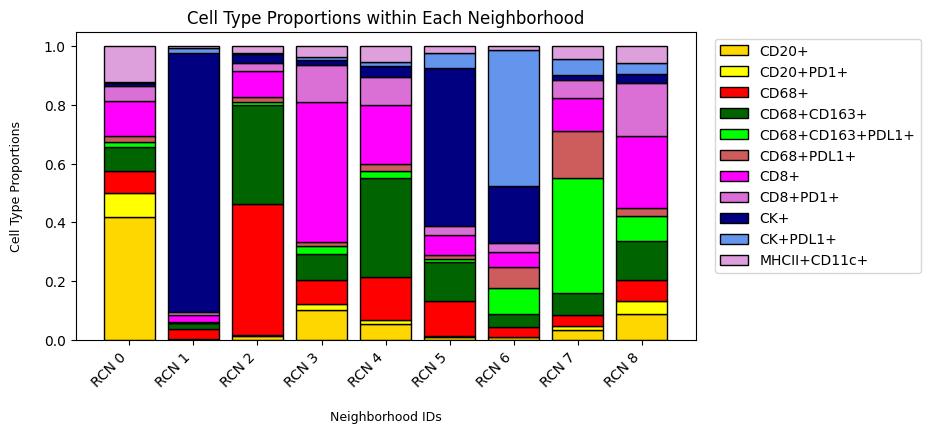

,CD20+,CD20+PD1+,CD68+,CD68+CD163+,CD68+CD163+PDL1+,CD68+PDL1+,CD8+,CD8+PD1+,CK+,CK+PDL1+,MHCII+CD11c+
0,0.417110,0.083858,0.074808,0.079589,0.017837,0.020824,0.120032,0.050283,0.009650,0.003224,0.122785
1,0.001052,0.000080,0.035680,0.019886,0.001110,0.003064,0.022427,0.011268,0.881019,0.020246,0.004169
2,0.013751,0.001273,0.448732,0.336009,0.009834,0.017873,0.087159,0.026874,0.030935,0.004162,0.023398
3,0.101012,0.021885,0.078941,0.091724,0.026568,0.013325,0.477724,0.125771,0.017011,0.010496,0.035543
4,0.055122,0.013563,0.146030,0.336145,0.025004,0.022992,0.202492,0.093439,0.039537,0.013194,0.052483
5,0.010438,0.001430,0.119639,0.134690,0.009911,0.014135,0.067729,0.031040,0.536201,0.053249,0.021538
6,0.007742,0.001337,0.033295,0.044472,0.087657,0.072219,0.051242,0.032272,0.193133,0.465794,0.010837
7,0.033598,0.013158,0.038745,0.074254,0.393054,0.158501,0.112153,0.061243,0.018798,0.053114,0.043382
8,0.087444,0.045239,0.071766,0.133434,0.082818,0.027719,0.245797,0.179395,0.031770,0.036762,0.057857


In [5]:
plot_neighbor_barstack(neighborhood_adata, neighborhood_key, type_key, cell_color_dict, save_fname='figures/neighborhood_compositions.svg')

In [6]:
neighborhood_adata_filtered = neighborhood_adata[neighborhood_adata.obs['outcome_response'].isin(['pCR', 'pNR'])]

unique_cell_types = np.unique(neighborhood_adata_filtered.obs[type_key])
unique_cluster_labels = np.unique(neighborhood_adata_filtered.obs[neighborhood_key])
unique_cluster_labels = np.sort(unique_cluster_labels.astype(int))
unique_cluster_labels = np.array([str(neighbor_label) for neighbor_label in unique_cluster_labels])
unique_outcomes = np.unique(neighborhood_adata_filtered.obs[outcome_key].values)
neighbor_type_proportion_dict = {}

for unique_label in unique_outcomes:
    sub_cell_proportion_dict = {cell_type: 0 for cell_type in unique_cluster_labels}
    neighbor_subset_frame = neighborhood_adata_filtered[neighborhood_adata_filtered.obs[outcome_key]==unique_label]
    # get counts of cell types belonging to that label
    neighbor_cell_types, neighbor_type_counts = np.unique(neighbor_subset_frame.obs[neighborhood_key], return_counts=True)

    for present_cell_index in range(len(neighbor_cell_types)):
        sub_cell_proportion_dict[neighbor_cell_types[present_cell_index]] += neighbor_type_counts[present_cell_index]

    neighbor_type_proportion_dict[unique_label] = sub_cell_proportion_dict

cell_neighbor_proportion_frame = pd.DataFrame(neighbor_type_proportion_dict).T
cell_neighbor_proportion_frame = cell_neighbor_proportion_frame.rename(columns={col_val: f'RCN {col_val}' for col_val in cell_neighbor_proportion_frame.columns})


In [7]:

# get a version of the frame with responder associated columns only
pnr_neighborhoods = ['RCN 1', 'RCN 5', 'RCN 6']
pcr_neighborhoods = [neighbor_name for neighbor_name in list(neigbhor_color_dict.keys()) if neighbor_name not in pnr_neighborhoods]

filtered_cell_neighbor_proportion_frame = cell_neighbor_proportion_frame[pcr_neighborhoods]

In [8]:
norm_term = np.sum(cell_neighbor_proportion_frame.values, axis=1).reshape(-1,1)
norm_values = cell_neighbor_proportion_frame.values/norm_term
norm_cell_neighbor_frame = pd.DataFrame(data=norm_values, index=cell_neighbor_proportion_frame.index, columns=cell_neighbor_proportion_frame.columns)

norm_term_filtered = np.sum(filtered_cell_neighbor_proportion_frame.values, axis=1).reshape(-1,1)
norm_values_filtered = filtered_cell_neighbor_proportion_frame.values/norm_term_filtered
norm_cell_neighbor_filtered_frame = pd.DataFrame(data=norm_values_filtered, index=filtered_cell_neighbor_proportion_frame.index, columns=filtered_cell_neighbor_proportion_frame.columns)

/mnt/c/users/hug18/documents/20_300_cscc_analysis/plotting_utils.py:260: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels([row_name for row_name in composition_rows])


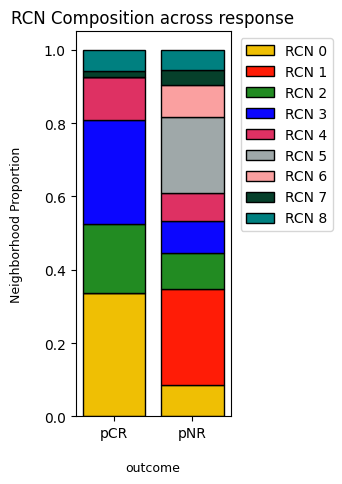

In [9]:
plot_stacked_bar(
    norm_cell_neighbor_frame,
    neigbhor_color_dict,
    title='RCN Composition across response',
    xlabel='outcome',
    ylabel='Neighborhood Proportion',
    save_fname='figures/neighborhood_proportion_pcr_vs_pnr.svg',
    figsize=(2,5),
    drop_x=False
)

/mnt/c/users/hug18/documents/20_300_cscc_analysis/plotting_utils.py:260: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels([row_name for row_name in composition_rows])


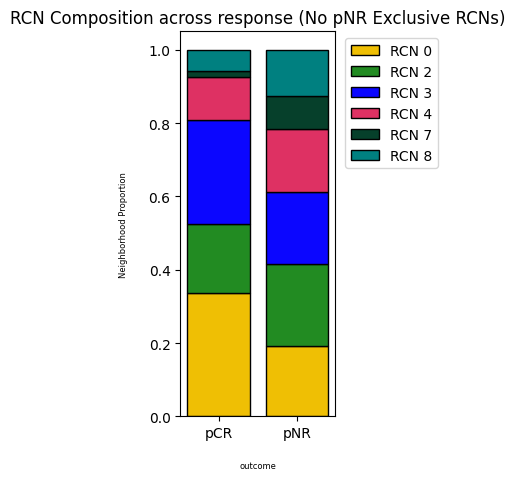

In [10]:
plot_stacked_bar(
    norm_cell_neighbor_filtered_frame,
    neigbhor_color_dict,
    title='RCN Composition across response (No pNR Exclusive RCNs)',
    xlabel='outcome',
    ylabel='Neighborhood Proportion',
    save_fname='figures/neighborhood_proportion_pcr_vs_pnr_exclusive_rcns_removed.svg',
    figsize=(2,5),
    drop_x=False
)

In [11]:
region_cell_threshold = 0
load_preexisting_regions = False

sample_key = 'src_image'
region_key = 'merged_region_name'
y_key = 'registered_wsi_cell_centroid_y_um'
x_key = 'registered_wsi_cell_centroid_x_um'
outcome_key = 'outcome_response'
overlap_key = 'overlap_identification_vec'

false_cells = ['unassigned', 'PD1+', 'MHCII+']
analysis_type = 'proportion'

In [12]:
neighbor_frame = neighborhood_adata.obs.copy()

In [13]:
neighbor_frame = neighbor_frame[neighbor_frame['outcome_response']!='pPR']

In [14]:
# drop unassigned cells
print(f'Num cells before dropping unassigned: {neighbor_frame.shape[0]}')
# neighbor_frame = neighbor_frame[neighbor_frame[type_key]!=false_cells]
neighbor_frame = neighbor_frame[~neighbor_frame[type_key].isin(false_cells)]
print(f'Num cells after dropping unassigned: {neighbor_frame.shape[0]}')

if not load_preexisting_regions:
    # perform region filtering here
    print(f'Filtering regions (Keeping regions with over {region_cell_threshold} cells)')
    region_names_to_keep = feature_filter_regions(
        neighbor_frame, 
        threshold_limit=region_cell_threshold,
        region_key=region_key,
    )


else:
    print(f'Loading predefined regions...')
    region_names_to_keep = pd.read_csv(os.path.join(region_path))
    region_names_to_keep = np.squeeze(region_names_to_keep.values)
    
print(len(region_names_to_keep))
    

Num cells before dropping unassigned: 5310853
Num cells after dropping unassigned: 5310853
Filtering regions (Keeping regions with over 0 cells)
Number of regions passing threshold: 21880
21880


In [15]:
neighbor_frame = neighbor_frame[neighbor_frame[region_key].isin(region_names_to_keep)]

In [16]:
neighbor_count_frame = neighbor_frame.pivot_table(
    index='src_image',
    columns=neighborhood_key,
    aggfunc='size',  # 'size' counts the number of non-NaN values in the group
    fill_value=0     # Replace NaN (samples without a specific cell type) with 0
).reset_index()      # Convert the 'src_image' index back into a column (optional)

/tmp/ipykernel_20798/2008005456.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  neighbor_count_frame = neighbor_frame.pivot_table(


In [17]:
valid_cluster_types = ['0', '2', '3', '4', '7', '8']

In [18]:
wsi_count_frame = pd.DataFrame(index=neighbor_count_frame['src_image'].values, data=neighbor_count_frame[valid_cluster_types].values, columns=valid_cluster_types)

In [19]:
regions_per_sample_series = neighbor_frame.groupby('src_image')['merged_region_name'].nunique()

/tmp/ipykernel_20798/2863921071.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regions_per_sample_series = neighbor_frame.groupby('src_image')['merged_region_name'].nunique()


In [20]:
exact_um_conversion = 0.4964
exact_mm_conversion = 0.4964/1000
row_size_px = 1000
col_size_px = 1300
height_um = row_size_px*exact_um_conversion
width_um = col_size_px*exact_um_conversion
area_um = height_um*width_um

# this is the area of a single ROI
height_mm = row_size_px*exact_mm_conversion
width_mm = col_size_px*exact_mm_conversion
area_mm = height_mm*width_mm

In [21]:
regions_per_sample_series = regions_per_sample_series*area_mm

In [22]:
outcome_mapping = neighbor_frame[['src_image', 'outcome_response']].drop_duplicates()

In [23]:
wsi_label_series = pd.Series(index=outcome_mapping['src_image'], data=outcome_mapping['outcome_response'].values)
wsi_label_series.value_counts()

pCR    15
pNR     8
pPR     0
Name: count, dtype: int64

In [24]:
if analysis_type=='density':
    wsi_density_frame = wsi_count_frame.div(regions_per_sample_series.values, axis=0)
elif analysis_type=='proportion':
    wsi_density_frame = wsi_count_frame.div(wsi_count_frame.sum(axis=1).values, axis=0)


In [25]:
neg_label = 'pNR'
if neg_label=='non-pCR':
    wsi_label_series = wsi_label_series.replace(['pNR', 'pPR'], ['non-pCR', 'non-pCR'])
    
wsi_stats = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, multi_method=None)

In [26]:
wsi_stats = wilcox_2_samp(wsi_density_frame, wsi_label_series, group_2_name=neg_label, alt_hyp='greater', multi_method=None)
wsi_stats[['AUC', 'p_val']].round(decimals=3)

,AUC,p_val
0,0.717,0.050
2,0.525,0.437
3,0.567,0.318
4,0.683,0.925
7,0.900,1.000
8,0.858,0.998


In [27]:
density_copy =  wsi_density_frame.copy()

In [28]:
if analysis_type=='proportion':
    ymax=1.1
    ymin=-0.1
else:
    ymax=1200
    ymin=-100
    y2_add = 20
    y1_add=20
    ast_add=20
    clipped_ymax=ymax-100

    
# density_copy[density_copy.values>clipped_ymax] = clipped_ymax    


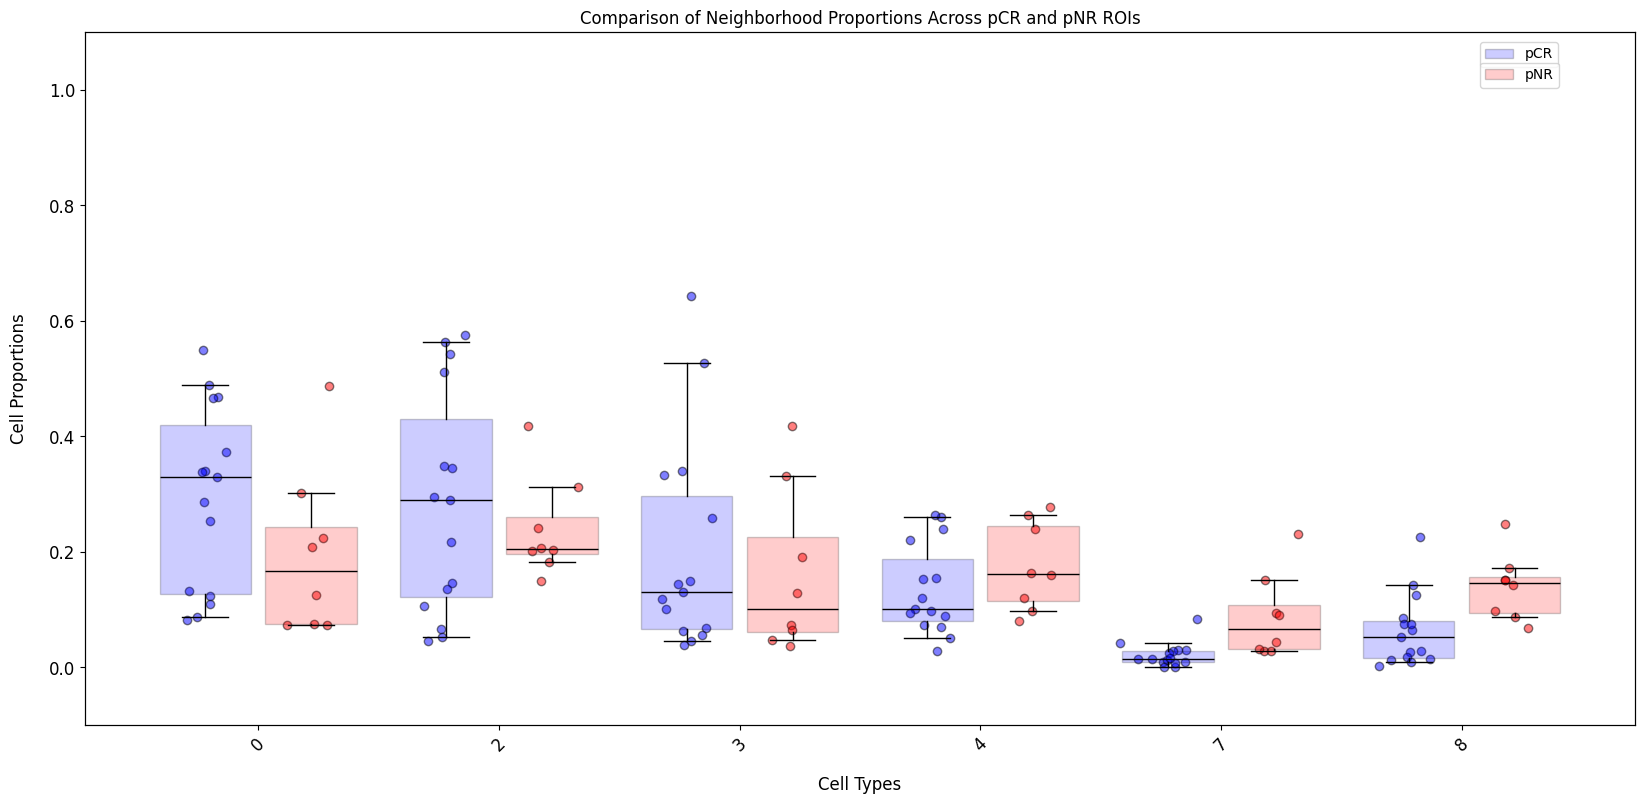

In [29]:
col_list = density_copy.columns.tolist()

fig, ax1 = plt.subplots(figsize=(20,9))

pos_samples = wsi_label_series[wsi_label_series=='pCR'].index.tolist()
neg_samples = wsi_label_series[wsi_label_series==neg_label].index.tolist()

num_groups = len(wsi_density_frame.columns.tolist())
# num_groups=1

box_param = dict(whis=(5, 95), widths=0.38, patch_artist=True,
                 flierprops=dict(marker='', markeredgecolor='black',
                 fillstyle=None), medianprops=dict(color='black'))

pos_frame = density_copy.loc[pos_samples]
neg_frame = density_copy.loc[neg_samples]


space=0.22
# for each category we want to plot the paired results
responder_positions = np.arange(num_groups)-space
non_responder_positions = np.arange(num_groups)+space

ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='blue', alpha=0.2), **box_param)
# x1_jitter = np.random.normal(i, 0.04, size=len(y))
# ax1.boxplot(pos_frame.values, positions=np.arange(num_groups)-space, boxprops=dict(facecolor='white'), **box_param)
for count, col_name in enumerate(pos_frame.columns.tolist()):
    x_pos = count-space
    col_vals = pos_frame[col_name].values
    x1_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax1.scatter(x1_jitter, col_vals, facecolors='blue', edgecolors='k', alpha=0.5)

ax1.set_ylim([ymin, ymax])
ax2 = ax1.twinx()
ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, boxprops=dict(facecolor='red', alpha=0.2), **box_param)
for count, col_name in enumerate(neg_frame.columns.tolist()):
    x_pos = count+space
    col_vals = neg_frame[col_name].values
    x2_jitter = np.random.normal(x_pos, 0.05, size=len(col_vals))
    ax2.scatter(x2_jitter, col_vals, facecolors='red', edgecolors='k', alpha=0.5)
# ax2.boxplot(neg_frame.values, positions=np.arange(num_groups)+space, **box_param)
ax2.set_ylim([ymin, ymax])

# format the p-values here
# x1, x2= 2,3
# y, h, col = max(map(max, region_densities.values)) + 2, 2, 'k'

# format x ticks
labelsize = 12
ax1.set_xticks(np.arange(num_groups))
ax1.set_xticklabels([f'{label}' for label in wsi_density_frame.columns.tolist()], rotation=45)

ax1.tick_params(axis='x', labelsize=labelsize)

# format y ticks
yticks_fmt = dict(axis='y', labelsize=labelsize)
ax1.tick_params(**yticks_fmt)
ax2.yaxis.set_ticklabels([])
ax2.yaxis.set_ticks([])

label_fmt = dict(size=12, labelpad=15)
ax1.set_xlabel('Cell Types', **label_fmt)
if analysis_type=='density':
    ax1.set_ylabel('Density (cells/mm\u00b2)', **label_fmt)
    plt.title(f'Comparison of Neighborhood Densities Across pCR and {neg_label} Slides')

elif analysis_type=='proportion':
    ax1.set_ylabel('Cell Proportions', **label_fmt)
    plt.title(f'Comparison of Neighborhood Proportions Across pCR and pNR ROIs')
    

# ax1.legend(['pCR'], title='* FDR=0.05', loc=(0.85,0.87))
# ax2.legend(['pNR'], loc=(0.85,0.8))
# plt.legend(title='* FDR=0.05', loc=(0.85, 0.70))
ax1.legend(['pCR'], loc=(0.90,0.95))
ax2.legend([f'{neg_label}'], loc=(0.90,0.92))

# use this one
if analysis_type=='density':
    fig.savefig(f'figures/neighborhood_wsi_density_plot.svg', dpi=450, bbox_inches='tight')
elif analysis_type=='proportion':
    fig.savefig(f'figures/neighborhood_wsi_proportion_plot.svg', dpi=450, bbox_inches='tight')


plt.show()